Please upload your CSV file.

In [14]:
uploaded_file = list(uploade().keys())[0]
df = pd.read_csv(uploaded_file)
display(df.head())

Saving heart.csv to heart.csv


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

HANDLE MISSING VALUES

In [17]:
print(df.isnull().sum())

imputer = SimpleImputer(strategy='mean')

df[df.columns] = imputer.fit_transform(df)

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


## Exploratory Data Analysis (EDA)

In [18]:
# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Exclude 'target' from numerical columns for feature analysis if it's there
if 'target' in numerical_cols:
    numerical_cols.remove('target')

print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")

Numerical columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Categorical columns: []


### Univariate Analysis: Distribution of Features

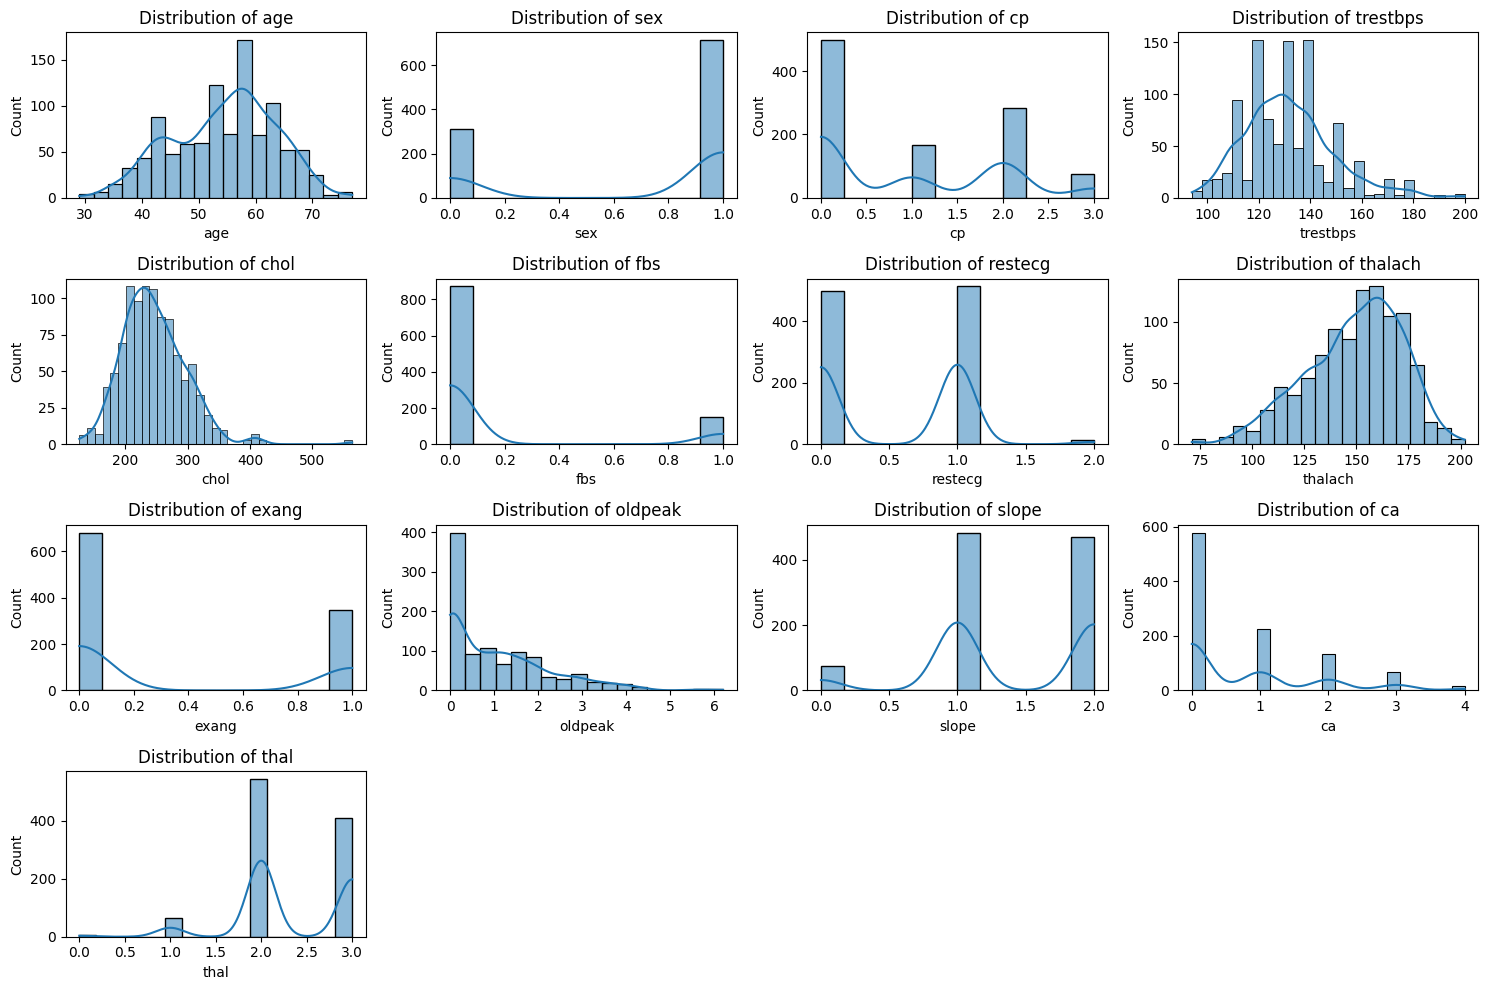

In [19]:
# Histograms for numerical features
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1) # Adjust subplot grid as needed
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

In [20]:
# Count plots for categorical features (if any)
if categorical_cols:
    plt.figure(figsize=(15, 5 * (len(categorical_cols) // 3 + 1)))
    for i, col in enumerate(categorical_cols):
        plt.subplot(len(categorical_cols) // 3 + 1, 3, i + 1)
        sns.countplot(x=col, data=df)
        plt.title(f'Count of {col}')
        plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns found for count plots.")

No categorical columns found for count plots.


### Bivariate Analysis: Features vs. Target Variable

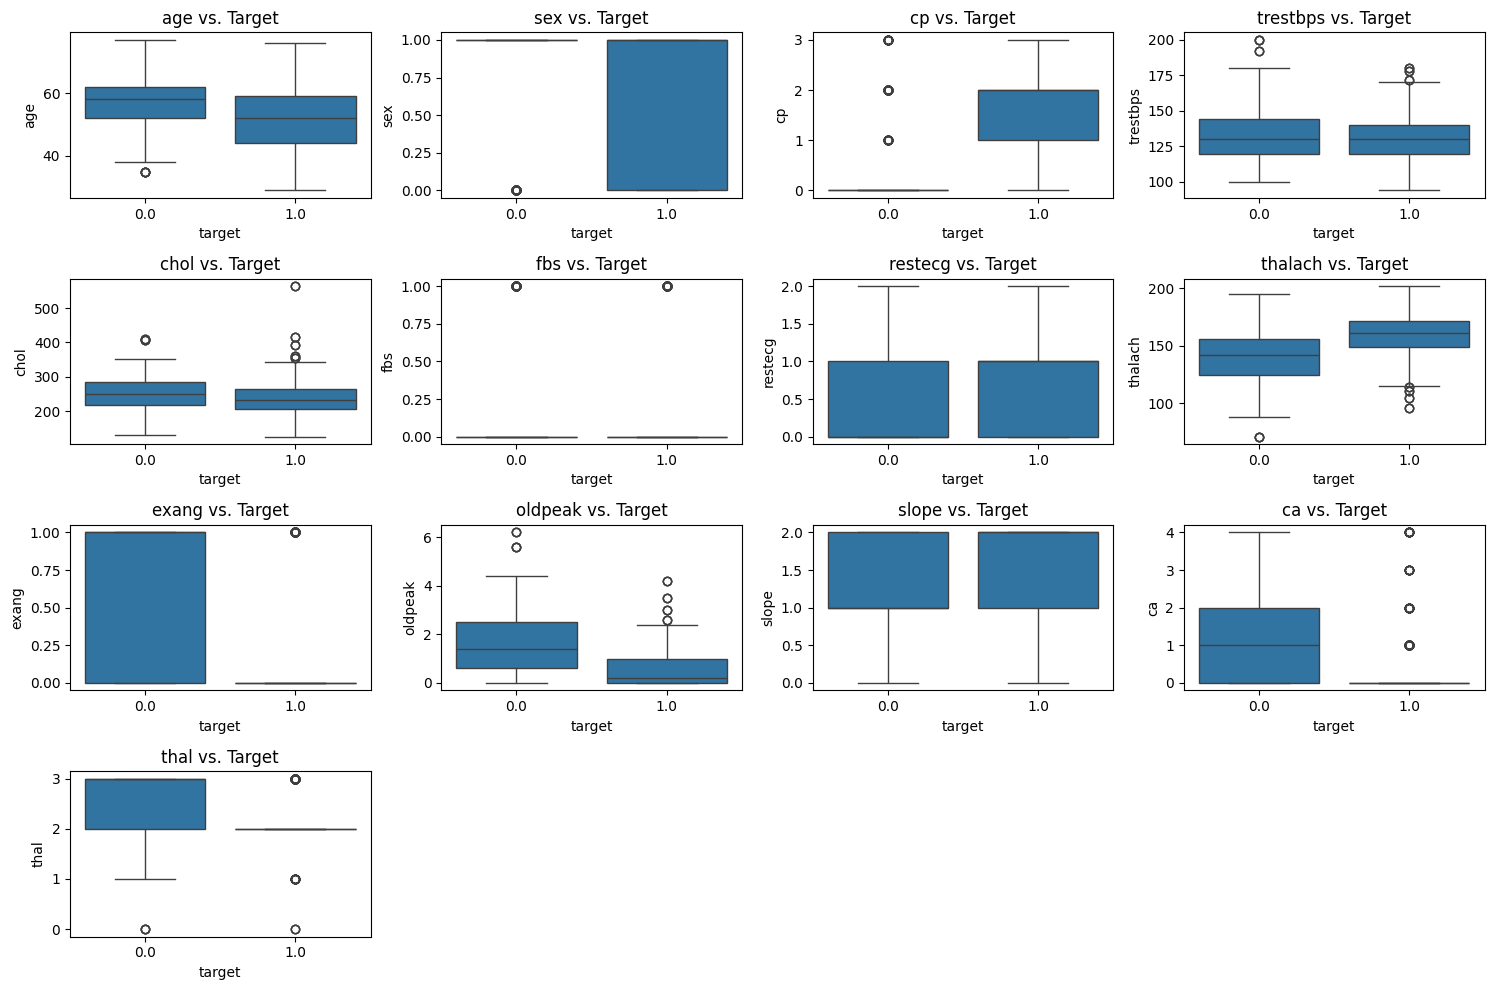

In [21]:
# Box plots for numerical features vs. target
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(x='target', y=col, data=df)
    plt.title(f'{col} vs. Target')
plt.tight_layout()
plt.show()

In [22]:
# Stacked bar plots for categorical features vs. target (if any)
if categorical_cols:
    plt.figure(figsize=(15, 5 * (len(categorical_cols) // 3 + 1)))
    for i, col in enumerate(categorical_cols):
        plt.subplot(len(categorical_cols) // 3 + 1, 3, i + 1)
        # Calculate proportion for stacked bar chart
        ct = pd.crosstab(df[col], df['target'], normalize='index')
        ct.plot(kind='bar', stacked=True, ax=plt.gca(), cmap='viridis')
        plt.title(f'{col} vs. Target')
        plt.ylabel('Proportion')
        plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns found for bivariate plots.")

No categorical columns found for bivariate plots.


### Correlation Matrix

In [ ]:
t

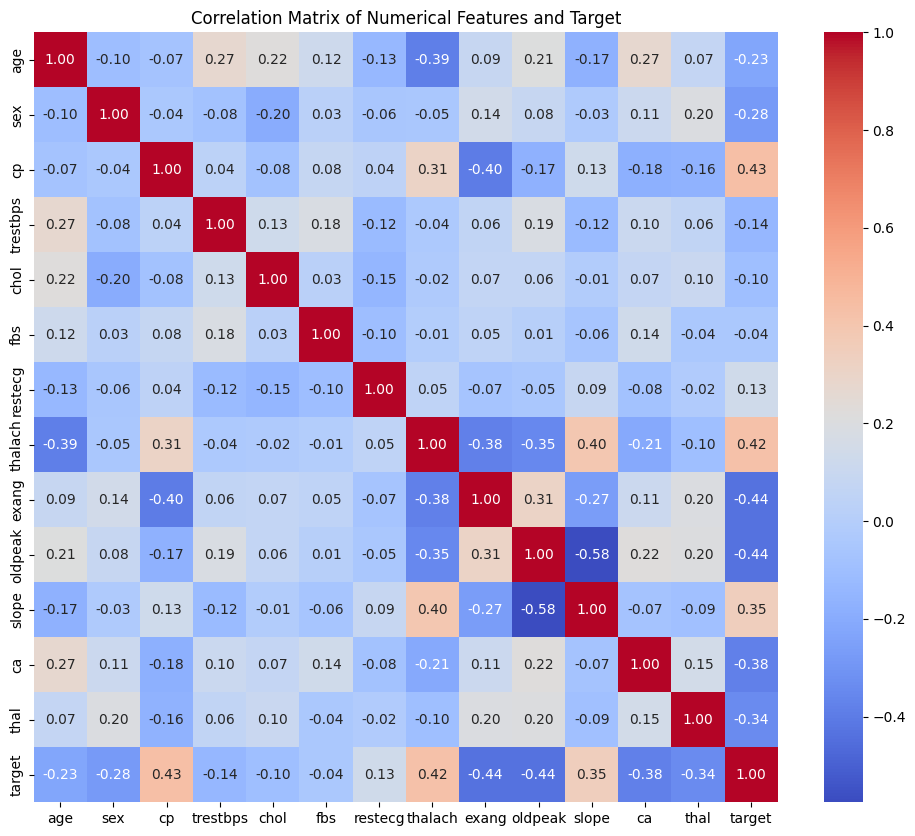

In [23]:
# Correlation matrix for numerical features
plt.figure(figsize=(12, 10))
sns.heatmap(df[numerical_cols + ['target']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features and Target')
plt.show()

## Feature Importance Analysis

In [24]:
# Separate features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# Initialize and train a RandomForestClassifier
# Using a small number of estimators for quick demonstration
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# Get feature importances
feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Feature Importances (Random Forest):")
display(feature_importances)

Feature Importances (Random Forest):


,0
cp,0.134201
thalach,0.120473
ca,0.116755
oldpeak,0.116151
thal,0.097043
age,0.089313
chol,0.078930
trestbps,0.074253
exang,0.059592
slope,0.048738


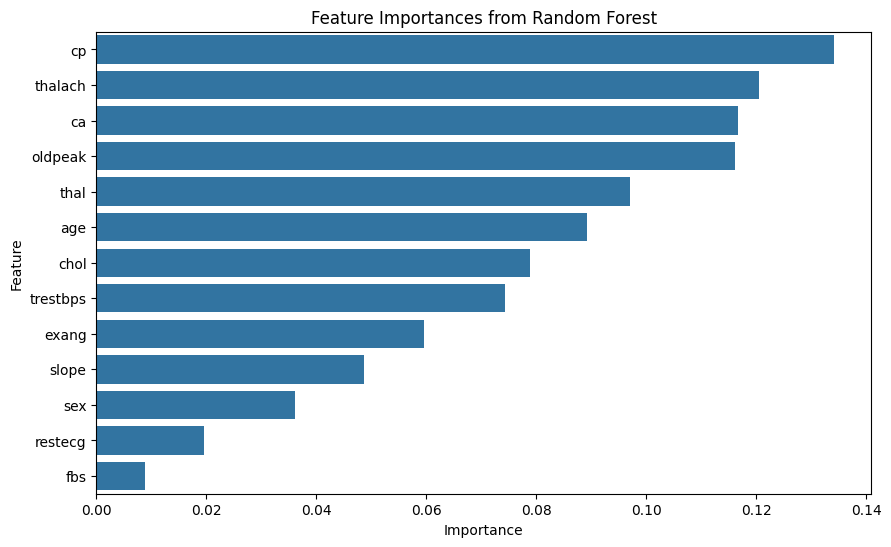

In [25]:
# Visualize feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index)
plt.title('Feature Importances from Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## Data Preprocessing: Feature Scaling

In [26]:
# Initialize StandardScaler
scaler = StandardScaler()

# Scale the numerical features (X)
X_scaled = scaler.fit_transform(X)

# Convert the scaled features back to a DataFrame for better readability
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Scaled DataFrame (first 5 rows):")
display(X_scaled_df.head())

Scaled DataFrame (first 5 rows):


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,-0.268437,0.661504,-0.915755,-0.377636,-0.659332,-0.418878,0.891255,0.821321,-0.712287,-0.060888,0.995433,1.209221,1.089852
1,-0.158157,0.661504,-0.915755,0.479107,-0.833861,2.387330,-1.004049,0.255968,1.403928,1.727137,-2.243675,-0.731971,1.089852
2,1.716595,0.661504,-0.915755,0.764688,-1.396233,-0.418878,0.891255,-1.048692,1.403928,1.301417,-2.243675,-0.731971,1.089852
3,0.724079,0.661504,-0.915755,0.936037,-0.833861,-0.418878,0.891255,0.516900,-0.712287,-0.912329,0.995433,0.238625,1.089852
4,0.834359,-1.511706,-0.915755,0.364875,0.930822,2.387330,0.891255,-1.874977,-0.712287,0.705408,-0.624121,2.179817,-0.522122


## Data Splitting

In [27]:
# Split the data into training and testing sets
# X_scaled_df contains the scaled features
# y contains the target variable
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (820, 13)
X_test shape: (205, 13)
y_train shape: (820,)
y_test shape: (205,)


## Model Training and Evaluation

### 1. Logistic Regression

In [28]:
# Initialize and train Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = log_reg_model.predict(X_test)
y_prob_lr = log_reg_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("Logistic Regression Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob_lr):.4f}")

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_lr), index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Performance:
Accuracy: 0.8098
Precision: 0.7619
Recall: 0.9143
F1-Score: 0.8312
ROC AUC Score: 0.9298

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,70,30
Actual 1,9,96



Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.70      0.78       100
         1.0       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205



### 2. K-Nearest Neighbors (KNN)

In [29]:
# Initialize and train KNN model
knn_model = KNeighborsClassifier(n_neighbors=5) # You can tune n_neighbors
knn_model.fit(X_train, y_train)

# Make predictions
y_pred_knn = knn_model.predict(X_test)
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("K-Nearest Neighbors Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_knn):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_knn):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob_knn):.4f}")

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_knn), index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

K-Nearest Neighbors Performance:
Accuracy: 0.8634
Precision: 0.8738
Recall: 0.8571
F1-Score: 0.8654
ROC AUC Score: 0.9626

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,87,13
Actual 1,15,90



Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.87      0.86       100
         1.0       0.87      0.86      0.87       105

    accuracy                           0.86       205
   macro avg       0.86      0.86      0.86       205
weighted avg       0.86      0.86      0.86       205



### 3. Random Forest Classifier

In [30]:
# Initialize and train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42) # You can tune n_estimators
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("Random Forest Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_rf), index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classifier Performance:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
ROC AUC Score: 1.0000

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,100,0
Actual 1,0,105



Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       100
         1.0       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



## Model Evaluation Function and Comparison

In [32]:
def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluates a given model and prints various performance metrics.
    """
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"--- {model_name} Performance ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
    print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

    print("\nConfusion Matrix:")
    display(pd.DataFrame(confusion_matrix(y_test, y_pred), index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("\n" + "="*50 + "\n")

    return y_prob

In [33]:
# Evaluate each model using the new function
y_prob_lr = evaluate_model(log_reg_model, X_test, y_test, "Logistic Regression")
y_prob_knn = evaluate_model(knn_model, X_test, y_test, "K-Nearest Neighbors")
y_prob_rf = evaluate_model(rf_model, X_test, y_test, "Random Forest Classifier")

--- Logistic Regression Performance ---
Accuracy: 0.8098
Precision: 0.7619
Recall: 0.9143
F1-Score: 0.8312
ROC AUC Score: 0.9298

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,70,30
Actual 1,9,96



Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.70      0.78       100
         1.0       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205



--- K-Nearest Neighbors Performance ---
Accuracy: 0.8634
Precision: 0.8738
Recall: 0.8571
F1-Score: 0.8654
ROC AUC Score: 0.9626

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,87,13
Actual 1,15,90



Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.87      0.86       100
         1.0       0.87      0.86      0.87       105

    accuracy                           0.86       205
   macro avg       0.86      0.86      0.86       205
weighted avg       0.86      0.86      0.86       205



--- Random Forest Classifier Performance ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
ROC AUC Score: 1.0000

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,100,0
Actual 1,0,105



Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       100
         1.0       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205





### Combined ROC Curve

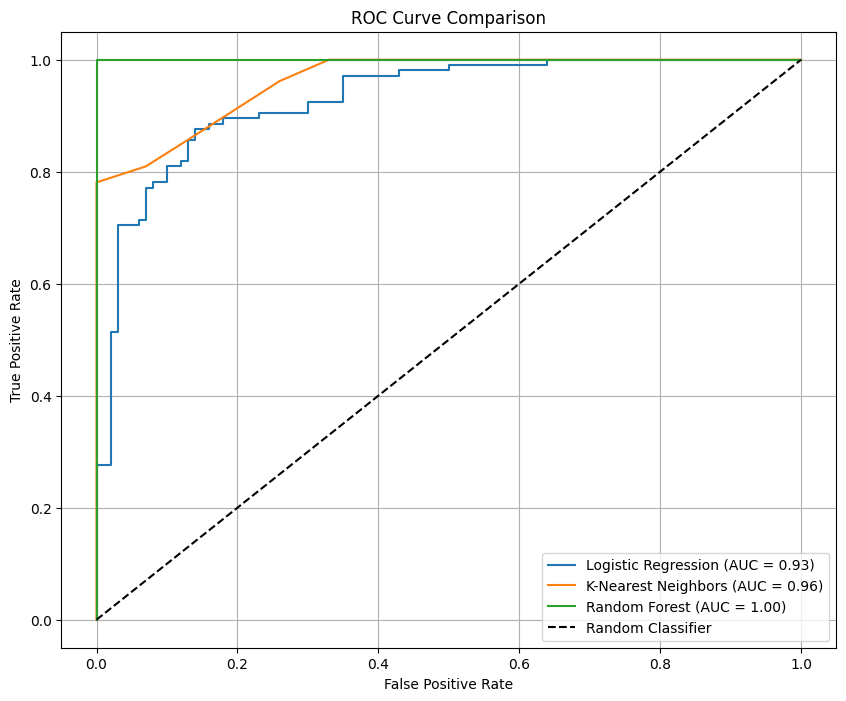

In [34]:
plt.figure(figsize=(10, 8))

# Plot ROC for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.2f})')

# Plot ROC for KNN
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
plt.plot(fpr_knn, tpr_knn, label=f'K-Nearest Neighbors (AUC = {roc_auc_score(y_test, y_prob_knn):.2f})')

# Plot ROC for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.2f})')

# Plot the random classifier line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

HEART DISEASE PRIDICTION


In [35]:
sample = np.array([
    [52,1,2,125,212,0,1,168,0,1.0,2,2,3]
])

sample = scaler.transform(sample)

prediction = rf_model.predict(sample)

if prediction[0] == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease")

Heart Disease Detected


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
